In [2]:
import os
import sys
import sctour as sct
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

In [ ]:
Classification = sys.argv[1]
dataset = sys.argv[2]
groupby = sys.argv[3]

In [2]:
#Classification='Classification_L4'
#dataset='Th2'

In [39]:
obj_path = f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{Classification}/{dataset}/'
sc.settings.figdir = obj_path

In [13]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_count_HVG.h5ad")

In [14]:
adt = sc.read_h5ad(f"{obj_path}{dataset}_scADT_count.h5ad")

In [15]:
indices = pd.read_csv(f"{obj_path}/{dataset}_indices_labels_umap.csv",index_col=0)

In [16]:
indices = indices[['Classification_L4','Classification_L3','Classification_L2','Classification_L1',
                   'leiden_cluster',
                   'UMAP_1','UMAP_2']]

In [17]:
if (adata.obs.index == indices.index).all():
    adata.obs = adata.obs.join(indices,how='left')
else:
    raise ValueError('Indices error.')

In [18]:
if (adata.obs.index == adt.obs.index).all():
    adata.obs['Batch'] = adt.obs['Batch'] 
else:
    raise ValueError('Indices error.')

In [19]:
adata.strings_to_categoricals()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical


In [20]:
adt.strings_to_categoricals()

In [21]:
if adata.X.max()>50:
    print('Process next step!')
else:
    raise ValueError('Not count data. Not process!')

Process next step!


In [27]:
sc.pp.calculate_qc_metrics(adata,inplace=True)

In [36]:
adata.obsm['X_umap'] = indices[['UMAP_1', 'UMAP_2']].values

# train trajectory

In [29]:
tnode = sct.train.Trainer(adata, loss_mode='nb', alpha_recon_lec=0.5, alpha_recon_lode=0.5)

Running using CPU.


In [30]:
tnode.train()

Epoch 231: 100%|██████████| 231/231 [29:14<00:00,  7.59s/epoch, train_loss=114, val_loss=114]


In [31]:
adata.obs['ptime'] = tnode.get_time()
mix_zs, zs, pred_zs = tnode.get_latentsp(alpha_z=0.5, alpha_predz=0.5)
adata.obsm['X_TNODE'] = mix_zs
adata.obsm['X_VF'] = tnode.get_vector_field(adata.obs['ptime'].values, adata.obsm['X_TNODE'])

/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/sctour/vector_field.py:109: RuntimeWarning: invalid value encountered in divide
  cos_sim = np.einsum("ij, j", dZ, V[i]) / (l2_norm(dZ, axis = 1) * l2_norm(V[i]))


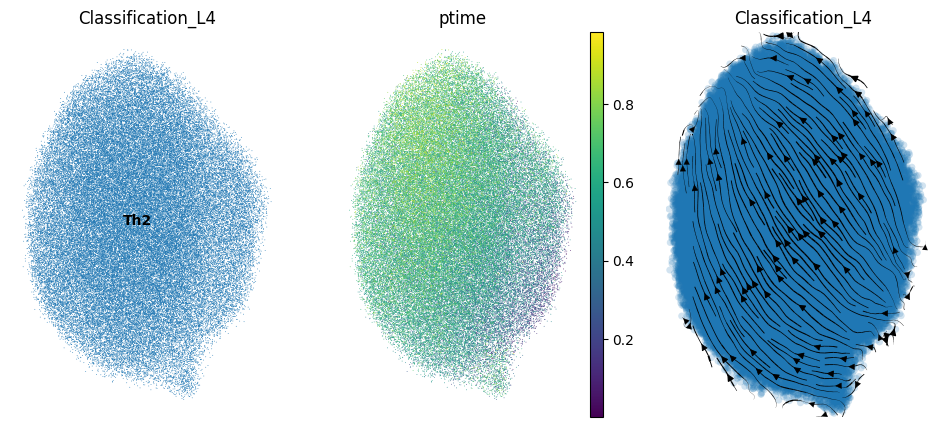

In [40]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 5))
sc.pl.umap(adata, color=groupby, ax=axs[0], legend_loc='on data', show=False, frameon=False)
sc.pl.umap(adata, color='ptime', ax=axs[1], show=False, frameon=False)
sct.vf.plot_vector_field(adata, zs_key='X_TNODE', vf_key='X_VF', use_rep_neigh='X_TNODE',
                         color=groupby, show=False, ax=axs[2], legend_loc='none', frameon=False, size=100, alpha=0.2)
plt.savefig(f"{obj_path}{dataset}_ptime.png")

/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/sctour/vector_field.py:109: RuntimeWarning: invalid value encountered in divide
  cos_sim = np.einsum("ij, j", dZ, V[i]) / (l2_norm(dZ, axis = 1) * l2_norm(V[i]))


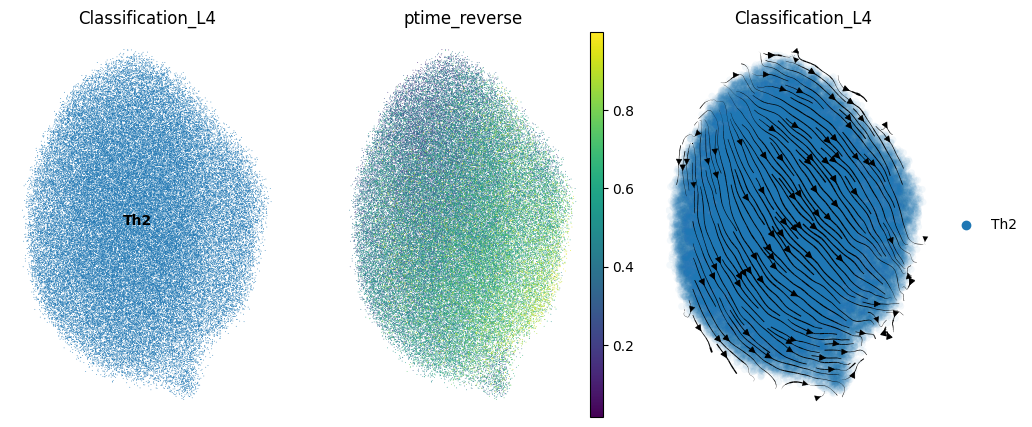

In [41]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 5))
sc.pl.umap(adata, color=groupby, ax=axs[0], legend_loc='on data', show=False, frameon=False)
adata.obs['ptime_reverse'] = sct.train.reverse_time(adata.obs['ptime'].values)
sc.pl.umap(adata, color='ptime_reverse', ax=axs[1], show=False, frameon=False)
sct.vf.plot_vector_field(adata, reverse=True, zs_key='X_TNODE', vf_key='X_VF', use_rep_neigh='X_TNODE',
                         color=groupby, show=False, ax=axs[2], frameon=False, size=100, alpha=0.05)
plt.savefig(f"{obj_path}{dataset}_reverse_ptime.png")